# CIFAR-10: Baseline PyTorch vs augmentations fortes + pipeline "sweet spot" (switch baseline→strong aug)

Objectif:
- Comparer **baseline** (augmentations classiques) vs **augmentations fortes** (RandAugment + ColorJitter + RandomErasing).
- Mesurer **accuracy**, **robustesse** (rotations + bruit gaussien), **temps**, et métriques complémentaires (**NLL**, **ECE**, confiance).
- Implémenter une stratégie **staged**: baseline jusqu’à stagnation puis strong aug.



In [ ]:
# Imports & seed
import time, copy, random, math
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


## 1) Datasets, transforms, loaders

Baseline PyTorch:
- RandomCrop + HorizontalFlip + Normalize

Augmentations fortes:
- RandomCrop + HorizontalFlip + RandAugment + ColorJitter + RandomErasing + Normalize


In [ ]:
# CIFAR-10 normalization
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)
normalize = transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)

# Global hyperparams
BATCH_SIZE = 128
NUM_WORKERS = 0
PIN_MEMORY = True
MAX_EPOCHS = 40

# Strong aug parameters (tune)
RAND_AUG_N = 2    # number of ops
RAND_AUG_M = 9    # magnitude (0..30)
CJITTER = dict(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
RE_PROB = 0.25
RE_SCALE = (0.02, 0.20)
RE_RATIO = (0.3, 3.3)

transform_train_baseline = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize,
])

transform_train_strong = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=RAND_AUG_N, magnitude=RAND_AUG_M),
    transforms.ColorJitter(**CJITTER),
    transforms.ToTensor(),
    transforms.RandomErasing(p=RE_PROB, scale=RE_SCALE, ratio=RE_RATIO, value='random'),
    normalize,
])

transform_val_clean = transforms.Compose([
    transforms.ToTensor(),
    normalize,
])

class TransformOverrideDataset(Dataset):
    def __init__(self, base_ds, transform):
        self.base_ds = base_ds
        self.transform = transform

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        img, y = self.base_ds.data[idx], self.base_ds.targets[idx]
        img = torchvision.transforms.functional.to_pil_image(img)
        if self.transform is not None:
            img = self.transform(img)
        return img, y

# Download once
trainset_base = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=None)
valset_base   = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=None)

trainset_baseline = TransformOverrideDataset(trainset_base, transform_train_baseline)
trainset_strong   = TransformOverrideDataset(trainset_base, transform_train_strong)
valset_clean      = TransformOverrideDataset(valset_base,   transform_val_clean)

trainloader_baseline = DataLoader(trainset_baseline, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
trainloader_strong   = DataLoader(trainset_strong,   batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
valloader_clean      = DataLoader(valset_clean,      batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Loaders ready.")


100%|██████████| 170M/170M [00:59<00:00, 2.86MB/s]


Loaders ready.


## 2) Modèle, entraînement, évaluation

- Modèle: ResNet18 (ImageNet pretrained optionnel)
- Optim: SGD+momentum, Cosine LR
- Arrêt stagnation (plateau): stop si pas d’amélioration de `val_clean_acc` pendant `patience` epochs.

Métriques:
- Accuracy clean
- Robustesse rotation (accuracy moyenne + drop + AUC)
- Robustesse bruit gaussien (moyenne + drop + AUC)
- NLL, ECE, confiance moyenne (correct vs incorrect)


In [ ]:
def build_resnet18_cifar10(pretrained: bool = True) -> nn.Module:
    if pretrained:
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    else:
        model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(device)

@torch.no_grad()
def accuracy_from_logits(logits, y):
    pred = logits.argmax(dim=1)
    correct = (pred == y).sum().item()
    return correct, y.numel()

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    total = 0
    correct = 0
    loss_sum = 0.0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        if criterion is not None:
            loss = criterion(logits, y)
            loss_sum += loss.item() * x.size(0)
        c, n = accuracy_from_logits(logits, y)
        correct += c
        total += n
    acc = 100.0 * correct / total
    loss_avg = (loss_sum / total) if criterion is not None else None
    return loss_avg, acc

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total = 0
    correct = 0
    loss_sum = 0.0
    for x, y in tqdm(loader, leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * x.size(0)
        c, n = accuracy_from_logits(logits, y)
        correct += c
        total += n

    return loss_sum/total, 100.0*correct/total

@torch.no_grad()
def get_prob_and_labels(model, loader):
    model.eval()
    probs_list = []
    y_list = []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        probs = torch.softmax(logits, dim=1).detach().cpu()
        probs_list.append(probs)
        y_list.append(y.cpu())
    return torch.cat(probs_list, dim=0), torch.cat(y_list, dim=0)

def nll_from_probs(probs, y):
    eps = 1e-12
    p = probs[torch.arange(probs.size(0)), y].clamp(min=eps)
    return float((-torch.log(p)).mean().item())

def ece_from_probs(probs, y, n_bins=15):
    conf, pred = probs.max(dim=1)
    acc = (pred == y).float()
    bins = torch.linspace(0, 1, n_bins+1)
    ece = torch.zeros(1)
    for i in range(n_bins):
        mask = (conf > bins[i]) & (conf <= bins[i+1])
        if mask.any():
            bin_conf = conf[mask].mean()
            bin_acc = acc[mask].mean()
            ece += (mask.float().mean()) * torch.abs(bin_conf - bin_acc)
    return float(ece.item())

def confidence_stats(probs, y):
    conf, pred = probs.max(dim=1)
    correct = (pred == y)
    c_mean = float(conf[correct].mean().item()) if correct.any() else float("nan")
    ic_mean = float(conf[~correct].mean().item()) if (~correct).any() else float("nan")
    return c_mean, ic_mean


## 3) Robustesse: rotation et bruit gaussien (validation)

Corruptions contrôlées:
- Rotation: angles (0,10,20,30,40)
- Bruit gaussien: sigmas (0, 0.02, 0.05, 0.10, 0.15)

On reporte aussi une AUC acc-vs-sévérité.


In [ ]:
def add_gaussian_noise(x: torch.Tensor, sigma: float) -> torch.Tensor:
    if sigma <= 0:
        return x
    return x + torch.randn_like(x) * sigma

def make_val_loader_rot(angle_deg: float):
    transform = transforms.Compose([
        transforms.RandomRotation(degrees=(angle_deg, angle_deg)),
        transforms.ToTensor(),
        normalize,
    ])
    ds = TransformOverrideDataset(valset_base, transform)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

def make_val_loader_gauss(sigma: float):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: add_gaussian_noise(x, sigma)),
        normalize,
    ])
    ds = TransformOverrideDataset(valset_base, transform)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

def auc_trapz(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    return float(np.trapz(y, x) / (x.max() - x.min() + 1e-12))

@torch.no_grad()
def robustness_rotation(model, angles=(0,10,20,30,40)):
    accs = {}
    for a in angles:
        loader = make_val_loader_rot(float(a))
        _, acc = evaluate(model, loader, criterion=None)
        accs[float(a)] = acc
    angles_sorted = sorted(accs.keys())
    acc_sorted = [accs[a] for a in angles_sorted]
    clean = accs.get(0.0, None)
    mean_nonzero = float(np.mean([accs[a] for a in angles_sorted if a != 0.0]))
    drop = (clean - mean_nonzero) if clean is not None else None
    auc = auc_trapz(angles_sorted, acc_sorted)
    return dict(acc_by_angle=accs, clean_acc=clean, mean_rot_acc=mean_nonzero, rot_drop=drop, rot_auc=auc)

@torch.no_grad()
def robustness_gaussian(model, sigmas=(0.0,0.02,0.05,0.10,0.15)):
    accs = {}
    for s in sigmas:
        loader = make_val_loader_gauss(float(s))
        _, acc = evaluate(model, loader, criterion=None)
        accs[float(s)] = acc
    sig_sorted = sorted(accs.keys())
    acc_sorted = [accs[s] for s in sig_sorted]
    clean = accs.get(0.0, None)
    mean_nonzero = float(np.mean([accs[s] for s in sig_sorted if s != 0.0]))
    drop = (clean - mean_nonzero) if clean is not None else None
    auc = auc_trapz(sig_sorted, acc_sorted)
    return dict(acc_by_sigma=accs, clean_acc=clean, mean_gauss_acc=mean_nonzero, gauss_drop=drop, gauss_auc=auc)


## 4) Entraînement avec arrêt plateau + logs complets

In [ ]:
def run_training(
    run_name: str,
    trainloaders_by_phase,   # list[(phase_name, loader, phase_epochs)]
    max_total_epochs=40,
    pretrained=True,
    lr=0.05,
    momentum=0.9,
    weight_decay=5e-4,
    patience=3,
    min_delta=0.05,
    eval_angles=(0,10,20,30,40),
    eval_sigmas=(0.0,0.02,0.05,0.10,0.15),
):
    model = build_resnet18_cifar10(pretrained=pretrained)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_total_epochs)

    history = []
    best_state = None
    best_val = -1.0
    bad_epochs = 0
    epoch_global = 0

    t0 = time.perf_counter()

    for phase_name, loader, phase_epochs in trainloaders_by_phase:
        for _ in range(int(phase_epochs)):
            epoch_global += 1
            if epoch_global > max_total_epochs:
                break

            ep0 = time.perf_counter()
            train_loss, train_acc = train_one_epoch(model, loader, criterion, optimizer)
            val_loss, val_acc = evaluate(model, valloader_clean, criterion=criterion)

            rot = robustness_rotation(model, angles=eval_angles)
            gau = robustness_gaussian(model, sigmas=eval_sigmas)
            probs, y = get_prob_and_labels(model, valloader_clean)
            nll = nll_from_probs(probs, y)
            ece = ece_from_probs(probs, y, n_bins=15)
            conf_c, conf_ic = confidence_stats(probs, y)

            scheduler.step()
            ep_time = time.perf_counter() - ep0

            history.append(dict(
                run=run_name,
                phase=phase_name,
                epoch=epoch_global,
                epoch_time_s=ep_time,
                train_loss=train_loss,
                train_acc=train_acc,
                val_loss=val_loss,
                val_clean_acc=val_acc,
                rot_mean_acc=rot["mean_rot_acc"],
                rot_drop=rot["rot_drop"],
                rot_auc=rot["rot_auc"],
                gauss_mean_acc=gau["mean_gauss_acc"],
                gauss_drop=gau["gauss_drop"],
                gauss_auc=gau["gauss_auc"],
                nll=nll,
                ece=ece,
                conf_correct_mean=conf_c,
                conf_incorrect_mean=conf_ic,
            ))

            if val_acc > best_val + min_delta:
                best_val = val_acc
                best_state = copy.deepcopy(model.state_dict())
                bad_epochs = 0
            else:
                bad_epochs += 1

            print(f"[{run_name}][{phase_name}] epoch {epoch_global:02d} | time {ep_time:.2f}s | val {val_acc:.2f}% | bad {bad_epochs}/{patience}")

            if bad_epochs >= patience:
                print(f"[{run_name}] STOP plateau: no improvement >= {min_delta}% for {patience} epochs.")
                break

        if epoch_global >= max_total_epochs or bad_epochs >= patience:
            break

    total_time = time.perf_counter() - t0

    if best_state is not None:
        model.load_state_dict(best_state)

    # Final eval (after best)
    final_val_loss, final_val_acc = evaluate(model, valloader_clean, criterion=criterion)
    final_rot = robustness_rotation(model, angles=eval_angles)
    final_gau = robustness_gaussian(model, sigmas=eval_sigmas)
    probs, y = get_prob_and_labels(model, valloader_clean)
    final_nll = nll_from_probs(probs, y)
    final_ece = ece_from_probs(probs, y, n_bins=15)
    conf_c, conf_ic = confidence_stats(probs, y)

    summary = dict(
        run=run_name,
        total_train_time_s=total_time,
        epochs_ran=len(history),
        best_val_clean_acc=final_val_acc,
        rot_mean_acc=final_rot["mean_rot_acc"],
        rot_drop=final_rot["rot_drop"],
        rot_auc=final_rot["rot_auc"],
        gauss_mean_acc=final_gau["mean_gauss_acc"],
        gauss_drop=final_gau["gauss_drop"],
        gauss_auc=final_gau["gauss_auc"],
        nll=final_nll,
        ece=final_ece,
        conf_correct_mean=conf_c,
        conf_incorrect_mean=conf_ic,
        rot_curve=final_rot["acc_by_angle"],
        gauss_curve=final_gau["acc_by_sigma"],
    )
    return model, pd.DataFrame(history), summary

def summarize_runs(summaries):
    rows = []
    for s in summaries:
        rows.append({k: s[k] for k in [
            "run","total_train_time_s","epochs_ran","best_val_clean_acc",
            "rot_mean_acc","rot_drop","rot_auc",
            "gauss_mean_acc","gauss_drop","gauss_auc",
            "nll","ece","conf_correct_mean","conf_incorrect_mean"
        ]})
    return pd.DataFrame(rows).sort_values("run")


## 5) Comparaison simple: baseline_only vs strong_only

In [ ]:
EVAL_ANGLES = (0, 10, 20, 30, 40)
EVAL_SIGMAS = (0.0, 0.02, 0.05, 0.10, 0.15)

baseline_model, baseline_hist, baseline_summary = run_training(
    run_name="baseline_only",
    trainloaders_by_phase=[("baseline", trainloader_baseline, MAX_EPOCHS)],
    max_total_epochs=MAX_EPOCHS,
    pretrained=True,
    lr=0.05,
    patience=6,
    min_delta=0.05,
    eval_angles=EVAL_ANGLES,
    eval_sigmas=EVAL_SIGMAS,
)

strong_model, strong_hist, strong_summary = run_training(
    run_name="strong_only",
    trainloaders_by_phase=[("strong", trainloader_strong, MAX_EPOCHS)],
    max_total_epochs=MAX_EPOCHS,
    pretrained=True,
    lr=0.05,
    patience=6,
    min_delta=0.05,
    eval_angles=EVAL_ANGLES,
    eval_sigmas=EVAL_SIGMAS,
)

df_cmp = summarize_runs([baseline_summary, strong_summary])
display(df_cmp)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 219MB/s]


  0%|          | 0/391 [00:00<?, ?it/s]

/tmp/ipython-input-4219820255.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x) / (x.max() - x.min() + 1e-12))


[baseline_only][baseline] epoch 01 | time 78.36s | val 39.14% | bad 0/6


...

  0%|          | 0/391 [00:00<?, ?it/s]

[strong_only][strong] epoch 39 | time 118.03s | val 86.21% | bad 0/6


  0%|          | 0/391 [00:00<?, ?it/s]

[strong_only][strong] epoch 40 | time 120.05s | val 86.19% | bad 1/6


,run,total_train_time_s,epochs_ran,best_val_clean_acc,rot_mean_acc,rot_drop,rot_auc,gauss_mean_acc,gauss_drop,gauss_auc,nll,ece,conf_correct_mean,conf_incorrect_mean
0,baseline_only,2996.046266,40,86.30,50.0725,36.2275,57.13375,66.2425,20.0575,67.973333,0.441834,0.054197,0.948370,0.720832
1,strong_only,4789.101655,40,86.21,60.6825,25.5275,67.10000,68.8250,17.3850,70.579000,0.409018,0.014572,0.911822,0.633557


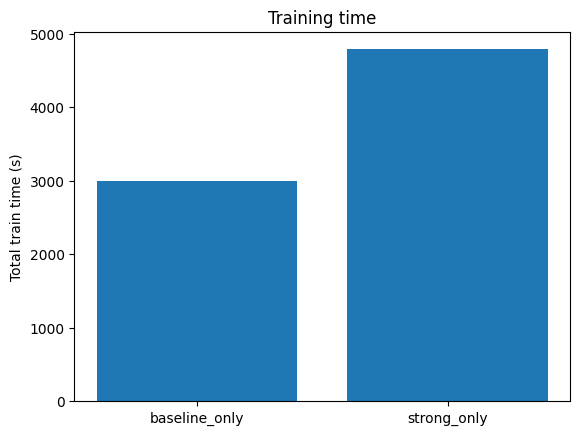

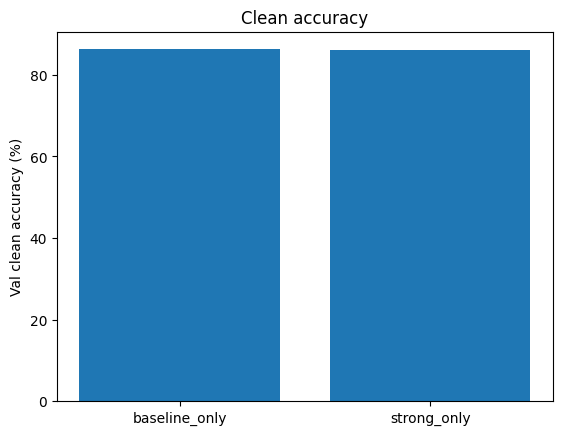

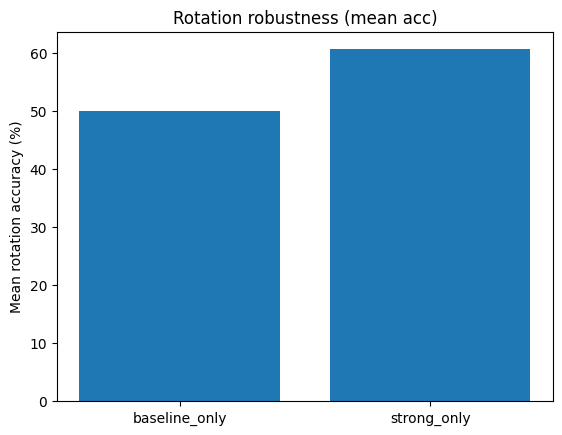

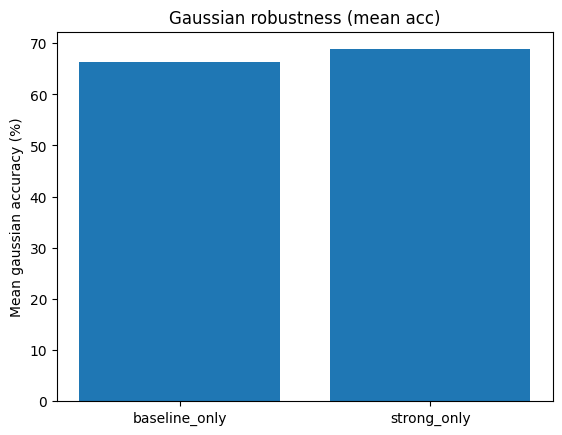

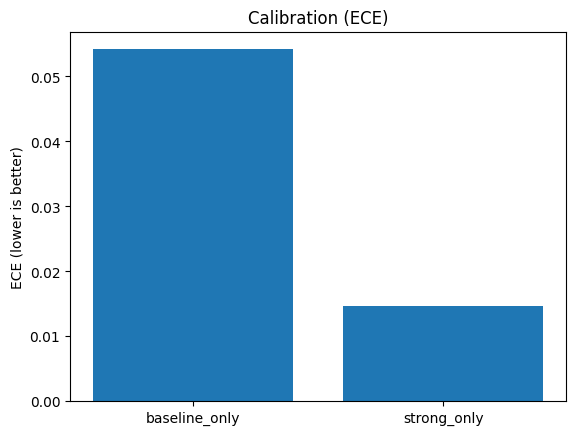

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_cmp["run"], df_cmp["total_train_time_s"])
plt.ylabel("Total train time (s)")
plt.title("Training time")
plt.show()

plt.figure()
plt.bar(df_cmp["run"], df_cmp["best_val_clean_acc"])
plt.ylabel("Val clean accuracy (%)")
plt.title("Clean accuracy")
plt.show()

plt.figure()
plt.bar(df_cmp["run"], df_cmp["rot_mean_acc"])
plt.ylabel("Mean rotation accuracy (%)")
plt.title("Rotation robustness (mean acc)")
plt.show()

plt.figure()
plt.bar(df_cmp["run"], df_cmp["gauss_mean_acc"])
plt.ylabel("Mean gaussian accuracy (%)")
plt.title("Gaussian robustness (mean acc)")
plt.show()

plt.figure()
plt.bar(df_cmp["run"], df_cmp["ece"])
plt.ylabel("ECE (lower is better)")
plt.title("Calibration (ECE)")
plt.show()


## 6) Pipeline sweet spot: baseline→strong

Deux variantes:
A) Switch à epoch fixe (grid sur `switch_epoch`).
B) Switch conditionnel: bascule dès plateau baseline (patience plus court), puis continuation en strong (LR réduit).

Score composite proposé:
`score = clean_acc + 0.5*rot_mean_acc + 0.5*gauss_mean_acc`


In [ ]:
def run_staged_fixed_switch(switch_epoch: int, total_epochs: int):
    phase1 = max(0, int(switch_epoch))
    phase2 = max(0, int(total_epochs - phase1))
    return run_training(
        run_name=f"staged_fixed_switch_e{switch_epoch}",
        trainloaders_by_phase=[
            ("baseline", trainloader_baseline, phase1),
            ("strong",   trainloader_strong,   phase2),
        ],
        max_total_epochs=total_epochs,
        pretrained=True,
        lr=0.05,
        patience=6,
        min_delta=0.05,
        eval_angles=EVAL_ANGLES,
        eval_sigmas=EVAL_SIGMAS,
    )

def run_staged_conditional_plateau(total_epochs: int, plateau_patience: int = 4, min_delta: float = 0.05):
    # Phase1: baseline until plateau (tight patience), then Phase2: strong until plateau (same patience)
    model, hist1, summ1 = run_training(
        run_name="staged_conditional",
        trainloaders_by_phase=[("baseline", trainloader_baseline, total_epochs)],
        max_total_epochs=total_epochs,
        pretrained=True,
        lr=0.05,
        patience=plateau_patience,
        min_delta=min_delta,
        eval_angles=EVAL_ANGLES,
        eval_sigmas=EVAL_SIGMAS,
    )
    e1 = len(hist1)
    remaining = max(0, total_epochs - e1)
    if remaining == 0:
        return model, hist1, summ1

    # Continue from current model state on strong aug (LR reduced)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=remaining)

    best_state = copy.deepcopy(model.state_dict())
    best_val = summ1["best_val_clean_acc"]
    bad = 0
    hist2 = []

    for i in range(1, remaining+1):
        ep0 = time.perf_counter()
        train_loss, train_acc = train_one_epoch(model, trainloader_strong, criterion, optimizer)
        val_loss, val_acc = evaluate(model, valloader_clean, criterion=criterion)

        rot = robustness_rotation(model, angles=EVAL_ANGLES)
        gau = robustness_gaussian(model, sigmas=EVAL_SIGMAS)
        probs, y = get_prob_and_labels(model, valloader_clean)
        nll = nll_from_probs(probs, y)
        ece = ece_from_probs(probs, y, n_bins=15)
        conf_c, conf_ic = confidence_stats(probs, y)

        scheduler.step()
        ep_time = time.perf_counter() - ep0

        hist2.append(dict(
            run="staged_conditional",
            phase="strong",
            epoch=e1 + i,
            epoch_time_s=ep_time,
            train_loss=train_loss,
            train_acc=train_acc,
            val_loss=val_loss,
            val_clean_acc=val_acc,
            rot_mean_acc=rot["mean_rot_acc"],
            rot_drop=rot["rot_drop"],
            rot_auc=rot["rot_auc"],
            gauss_mean_acc=gau["mean_gauss_acc"],
            gauss_drop=gau["gauss_drop"],
            gauss_auc=gau["gauss_auc"],
            nll=nll,
            ece=ece,
            conf_correct_mean=conf_c,
            conf_incorrect_mean=conf_ic,
        ))

        if val_acc > best_val + min_delta:
            best_val = val_acc
            best_state = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1

        print(f"[staged_conditional][strong] epoch {e1+i:02d} | time {ep_time:.2f}s | val {val_acc:.2f}% | bad {bad}/{plateau_patience}")
        if bad >= plateau_patience:
            break

    # load best and summarize
    model.load_state_dict(best_state)
    criterion = nn.CrossEntropyLoss()
    _, final_acc = evaluate(model, valloader_clean, criterion=criterion)
    final_rot = robustness_rotation(model, angles=EVAL_ANGLES)
    final_gau = robustness_gaussian(model, sigmas=EVAL_SIGMAS)
    probs, y = get_prob_and_labels(model, valloader_clean)
    final_nll = nll_from_probs(probs, y)
    final_ece = ece_from_probs(probs, y, n_bins=15)
    conf_c, conf_ic = confidence_stats(probs, y)

    hist_all = pd.concat([hist1, pd.DataFrame(hist2)], ignore_index=True)
    summ = dict(
        run="staged_conditional",
        total_train_time_s=float(hist_all["epoch_time_s"].sum()),
        epochs_ran=len(hist_all),
        best_val_clean_acc=final_acc,
        rot_mean_acc=final_rot["mean_rot_acc"],
        rot_drop=final_rot["rot_drop"],
        rot_auc=final_rot["rot_auc"],
        gauss_mean_acc=final_gau["mean_gauss_acc"],
        gauss_drop=final_gau["gauss_drop"],
        gauss_auc=final_gau["gauss_auc"],
        nll=final_nll,
        ece=final_ece,
        conf_correct_mean=conf_c,
        conf_incorrect_mean=conf_ic,
        rot_curve=final_rot["acc_by_angle"],
        gauss_curve=final_gau["acc_by_sigma"],
    )
    return model, hist_all, summ

def score(summary, w_rot=0.5, w_gau=0.5):
    return summary["best_val_clean_acc"] + w_rot*summary["rot_mean_acc"] + w_gau*summary["gauss_mean_acc"]


In [ ]:
SWITCH_EPOCHS = [3, 6, 9, 12]
staged_summaries = []
staged_hists = {}
MAX_EPOCHS = 15

for se in SWITCH_EPOCHS:
    m, h, s = run_staged_fixed_switch(se, total_epochs=MAX_EPOCHS)
    staged_summaries.append(s)
    staged_hists[s["run"]] = h

m_cond, h_cond, s_cond = run_staged_conditional_plateau(total_epochs=MAX_EPOCHS, plateau_patience=4, min_delta=0.05)
staged_summaries.append(s_cond)
staged_hists[s_cond["run"]] = h_cond

df_staged = summarize_runs(staged_summaries)
df_staged["score"] = [score(s) for s in staged_summaries]
display(df_staged.sort_values("score", ascending=False))


  0%|          | 0/391 [00:00<?, ?it/s]

/tmp/ipython-input-4219820255.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x) / (x.max() - x.min() + 1e-12))


[staged_fixed_switch_e3][baseline] epoch 01 | time 74.44s | val 25.79% | bad 0/6


  0%|          | 0/391 [00:00<?, ?it/s]

[staged_fixed_switch_e3][baseline] epoch 02 | time 73.22s | val 34.55% | bad 0/6


...

  0%|          | 0/391 [00:00<?, ?it/s]

[staged_conditional][baseline] epoch 14 | time 73.76s | val 81.77% | bad 0/4


  0%|          | 0/391 [00:00<?, ?it/s]

[staged_conditional][baseline] epoch 15 | time 73.72s | val 82.26% | bad 0/4


,run,total_train_time_s,epochs_ran,best_val_clean_acc,rot_mean_acc,rot_drop,rot_auc,gauss_mean_acc,gauss_drop,gauss_auc,nll,ece,conf_correct_mean,conf_incorrect_mean,score
0,staged_fixed_switch_e3,1689.228405,15,75.64,51.1800,24.4600,56.85875,60.3225,15.3175,61.864000,0.703635,0.011065,0.825063,0.568865,144.47125
2,staged_fixed_switch_e9,1397.457630,15,82.55,58.3200,24.2300,64.06625,65.5225,17.0275,67.109333,0.505138,0.009811,0.879654,0.596870,140.22250
4,staged_conditional,1117.229697,15,82.26,50.3625,31.8975,56.82500,65.5625,16.6975,66.957667,0.516562,0.024978,0.895049,0.626005,131.39125
1,staged_fixed_switch_e6,1505.523729,15,71.16,47.0725,24.0875,52.42250,62.4475,8.7125,63.423000,0.821445,0.008672,0.779849,0.532912,127.65500
3,staged_fixed_switch_e12,1263.855359,15,73.92,45.3400,28.5800,50.88250,62.1300,11.7900,63.274000,0.756728,0.022984,0.821399,0.583034,125.92000


In [ ]:
all_summaries = [baseline_summary, strong_summary] + staged_summaries
df_all = summarize_runs(all_summaries)
df_all["score"] = [score(s) for s in all_summaries]
df_all = df_all.sort_values("score", ascending=False)
display(df_all)


In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_all["total_train_time_s"], df_all["score"])
for _, r in df_all.iterrows():
    plt.text(r["total_train_time_s"], r["score"], r["run"], fontsize=8)
plt.xlabel("Total train time (s)")
plt.ylabel("Score = clean + 0.5*rot_mean + 0.5*gauss_mean")
plt.title("Time vs composite score")
plt.show()


## 7) Sélection automatique du sweet spot

On extrait:
- le meilleur run global
- le meilleur run sous contrainte de temps (<= temps baseline_only)


In [ ]:
best_overall = df_all.iloc[0]
print("Best overall:", best_overall["run"])
print(best_overall)

baseline_time = float(df_cmp[df_cmp["run"]=="baseline_only"]["total_train_time_s"].iloc[0])
df_under = df_all[df_all["total_train_time_s"] <= baseline_time].copy()
if len(df_under) > 0:
    best_under = df_under.sort_values("score", ascending=False).iloc[0]
    print("\nBest under baseline_only time:", best_under["run"])
    print(best_under)
else:
    print("\nNo run under baseline_only time (adjust patience/min_delta/MAX_EPOCHS).")


## 8) Sauvegarde CSV (pour le rapport)

- `comparison_runs.csv`
- `history_*.csv`


In [ ]:
df_all.to_csv("comparison_runs.csv", index=False)
baseline_hist.to_csv("history_baseline_only.csv", index=False)
strong_hist.to_csv("history_strong_only.csv", index=False)
for run, h in staged_hists.items():
    h.to_csv(f"history_{run}.csv", index=False)

print("Saved: comparison_runs.csv and history_*.csv")


NameError: name 'df_all' is not defined